In [143]:
import statsmodels.formula.api as sm
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
from matplotlib.lines import Line2D
import seaborn as sns
import pandas as pd
import numpy as np
from statsmodels.stats.anova import anova_lm
from statsmodels.formula.api import logit, ols
from statsmodels.tools import add_constant

# Load and clean up data

### Debugg `jsonl` files

In [64]:
groups = ['blocked', 'interleaved', 'free', 'post']
for group in groups:
    pathin = f'pilots/pilots_Dec2022/{group}.txt'
    pathout = f'pilots/pilots_Dec2022/{group}_valid.jsonl'
    with open(pathin, 'rt') as fin:
        with open(pathout, 'wt') as fout:
            for line in fin:
                if "originalEvent" in line:
                    continue
                fout.write(line.replace('}{', '}\n{'))

In [65]:
DF = pd.concat([pd.read_json(f'pilots/pilots_Dec2022/{group}_valid.jsonl', lines=True) for group in groups], axis=0)
DF['pid'] = DF.prolificPID.astype('category').cat.codes

# Drop unwanted columns and delete interim variables
DF = DF.drop(columns=['prolificStudyID', 'prolificPID', 'dt'])

# Drop participants with less than 216 trials in free stage
DF['numTrainTrials'] = DF.groupby('pid')['feedbackOn'].transform(lambda s: s.sum())
DF = DF[DF.numTrainTrials.ge(215)]

DF = DF.sort_values(by=['pid', 'stage', 'trialsComplete'])

# Add condition column
DF['condition'] = DF.groupby('pid')['stage'].transform(lambda series: series.iloc[0].split('_')[0])

display(DF.head())
print('Unique conditions:', DF.condition.unique())
print('Number of rows with at least 1 nan: ', DF.isna().any(axis=1).sum())
print(DF.to_csv('pilots/pilots_Dec2022/combined.csv'))

,stage,feedbackOn,trialsComplete,famInd,features,rule,responseOrder,correctResponse,guess,confidence,correct,rt,pid,numTrainTrials,condition
0,interleaved_epochs,True,1,3,"[5, 6]",2d1,"[5, 3]",3,5,0.42,False,5898,0,216,interleaved
1,interleaved_epochs,True,2,4,"[4, 1]",2d1,"[6, 7]",6,7,0.64,False,4000,0,216,interleaved
2,interleaved_epochs,True,3,1,"[5, 2]",2d1,"[2, 0]",0,0,0.56,True,3887,0,216,interleaved
3,interleaved_epochs,True,4,1,"[1, 6]",2d1,"[2, 0]",2,0,0.52,False,3986,0,216,interleaved
4,interleaved_epochs,True,5,3,"[5, 5]",2d1,"[5, 3]",3,3,0.80,True,4328,0,216,interleaved


Unique conditions: ['interleaved' 'blocked' 'free']
Number of rows with at least 1 nan:  0
None


# Simple proportion correct across time during practice

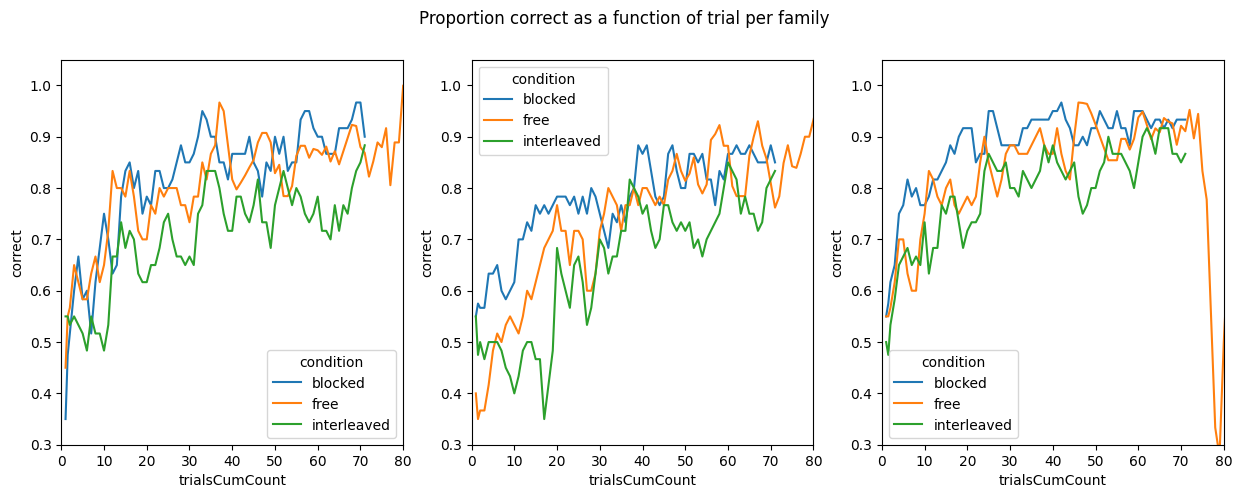

In [149]:
df = DF[DF.feedbackOn][['condition', 'famInd', 'trialsComplete', 'correct', 'pid']]
df['trialsCumCount'] = (df.groupby(['pid', 'famInd']).cumcount() + 1).astype(int)
df.sort_values(by=['condition', 'pid', 'trialsComplete']).to_csv('tamp.csv', index=False)
df = df.groupby(['condition', 'famInd', 'trialsCumCount']).mean().reset_index()
df = df.groupby(['condition', 'famInd']).rolling(3, min_periods=1).mean().reset_index()
fig = plt.figure(figsize=[15, 5])
for i, fam in enumerate([1, 3, 4]):
    ax = fig.add_subplot(1, 3, i+1)
    ax.set_ylim(0.3, 1.05)
    ax.set_xlim(0, 80)
    plotdf = df[df.famInd.eq(fam)]
    sns.lineplot(x='trialsCumCount', y='correct', hue='condition', data=plotdf, ax=ax)
plt.suptitle('Proportion correct as a function of trial per family')
plt.savefig('plots/pcPerTrialPerFam.png')

# Test 1 and 2 performance

,sum_sq,df,F,PR(>F)
condition,0.014122,2.0,0.462034,0.632664
Residual,0.764148,50.0,NaN,NaN


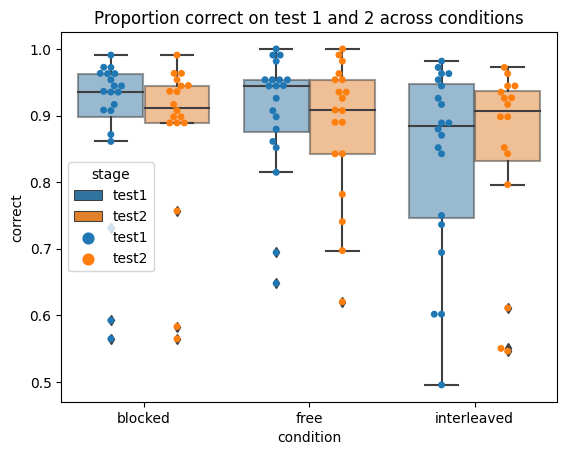

In [151]:
df = DF[~DF.feedbackOn][['pid', 'condition', 'stage', 'correct', 'confidence']]
df = df.groupby(['condition', 'pid', 'stage']).mean().reset_index()
df = df.sort_values(by=['condition', 'pid', 'stage'])

sns.boxplot(x='condition', y='correct', hue='stage', boxprops=dict(alpha=.5), data=df)
sns.swarmplot(x='condition', y='correct', hue='stage', dodge=True, data=df)

linmod = ols('correct ~ condition', data=df[df.stage.eq('test2')]).fit()
anova_table = anova_lm(linmod, typ=2)
display(anova_table)
plt.title('Proportion correct on test 1 and 2 across conditions')
plt.savefig('plots/testsPerCondition.png')

# Test 1 and 2 contrasts

,condition,pid,correct,confidence
0,blocked,2,0.009259,-0.088704
1,blocked,6,-0.028956,0.008025
2,blocked,8,-0.018519,0.002037
3,blocked,9,0.026589,-0.032640
4,blocked,15,-0.046296,-0.132315


,sum_sq,df,F,PR(>F)
condition,0.002168,2.0,0.721537,0.49039
Residual,0.085648,57.0,NaN,NaN


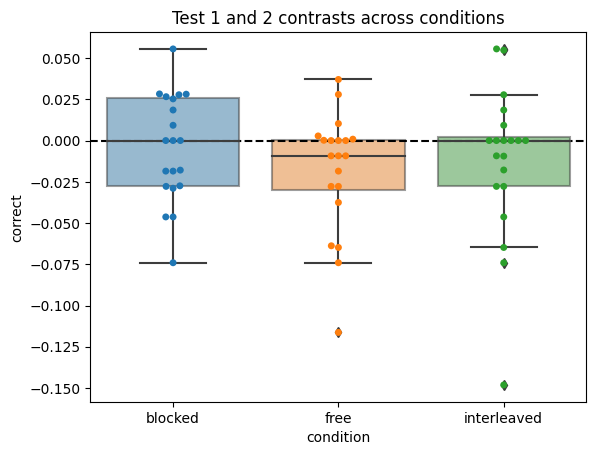

In [152]:
df = DF[~DF.feedbackOn][['pid', 'condition', 'stage', 'correct', 'confidence']]
df = df.groupby(['condition', 'pid', 'stage']).mean().reset_index()
df = df.sort_values(by=['condition', 'pid', 'stage'])
df = df.groupby(['condition', 'pid'])[['correct', 'confidence']].apply(lambda sdf: sdf.iloc[-1, :] - sdf.iloc[0, :]).reset_index()

sns.boxplot(y='correct', x='condition', boxprops=dict(alpha=.5), data=df)
sns.swarmplot(y='correct', x='condition', dodge=True, data=df)
plt.gca().axhline(0, ls='--', color='k')

display(df.head())
linmod = ols('correct ~ condition', data=df).fit()
anova_table = anova_lm(linmod, typ=2)
display(anova_table)
plt.title('Test 1 and 2 contrasts across conditions')
plt.savefig('plots/testsDiffPerCondition.png')